In [78]:
# Student information
print("\n" + "=" * 80)
print("\033[1mEnd Of Semester Project\033[0m")
print("\033[1mName of Student: Joseph Dabuo\033[0m")
print("\033[1mRoll Number: 10022200160\033[0m")
print("\033[1mCourse: Biomedical Data Analysis with AI (BE4182)\033[0m")
print("\033[1mProject Title: Parkinson's Disease Voice Screening\033[0m")
print("\033[1mDate: 12/22/2025\033[0m")
print("=" * 80 + "\n")


End Of Semester Project
Name of Student: Joseph Dabuo
Roll Number: 10022200160
Course: Biomedical Data Analysis with AI (BE4182)
Project Title: Parkinson's Disease Voice Screening
Date: 12/22/2025



In [79]:
# Importing libraries and setting basic plotting style

import numpy as np                      # numerical operations and arrays
import pandas as pd                     # working with tabular data (DataFrame)
import matplotlib.pyplot as plt         # basic plotting
import seaborn as sns                   # high-level plotting

from sklearn.model_selection import train_test_split    # split data into train and test
from sklearn.model_selection import GroupShuffleSplit   # create a group-aware train–test splitter
from sklearn.model_selection import GroupKFold          # group-aware cross-validation
from sklearn.preprocessing import StandardScaler        # scale/standardize features
from sklearn.decomposition import PCA                   # Principal Component Analysis (PCA)

from sklearn.metrics import (                          # metrics to judge model performance
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression     # baseline linear classifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC                             # Support Vector Machine classifier

from imblearn.over_sampling import SMOTE                # oversampling technique for imbalanced data

import joblib                                           # saving and loading trained model

import warnings
warnings.filterwarnings("ignore")                       # hide non-critical warnings to keep output clean

print("Libraries loaded for the analysis!")

Libraries loaded for the analysis!


In [80]:
# Loading the Parkinson's voice dataset

# Each row is a voice recording with acoustic features
# and a 'status' label:
#   status = 1 → Parkinson's disease
#   status = 0 → healthy control

voice_df = pd.read_csv("parkinsons.csv")

print("Data shape (rows, columns):", voice_df.shape) # Number of rows and columns

# View the first five rows
voice_df.head()

Data shape (rows, columns): (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [81]:
# Data inspection

# Here we check column types, non-null counts
# and get a quick numeric summary. This helps us
# understand what features we have and detect obvious issues.

print("=== INFO ===")
print(voice_df.info()) # Data types and missing values

print("\n=== NUMERIC SUMMARY ===")
display(voice_df.describe().T) # Summary statistics

print("\nColumns in dataset:")
print(voice_df.columns.tolist()) # Print the column names of the DataFrame as a list

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null 

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000



Columns in dataset:
['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


=== Class counts ===
status
1    147
0     48
Name: count, dtype: int64

=== Class proportions (%) ===
status
1    75.384615
0    24.615385
Name: proportion, dtype: float64


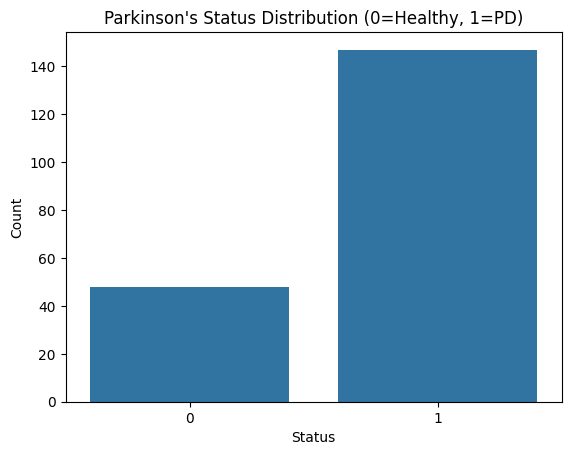

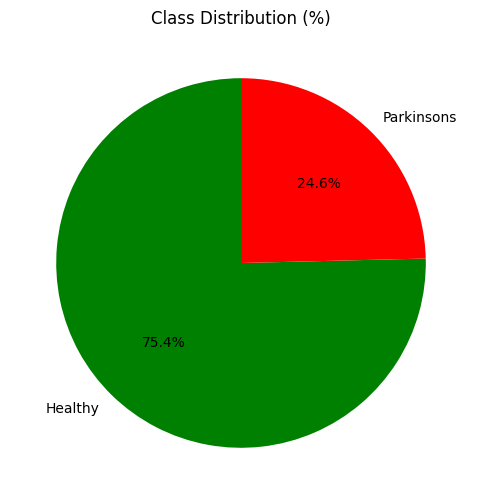

In [82]:
# Target distribution (0 = Healthy, 1 = Parkinson's)

# This shows if the dataset is imbalanced. Parkinson's datasets
# often have more PD recordings than healthy controls.

target_col = "status"

print("=== Class counts ===")
print(voice_df[target_col].value_counts())

print("\n=== Class proportions (%) ===")
print(voice_df[target_col].value_counts(normalize=True) * 100)

# Class distribution bar chart
sns.countplot(x=voice_df[target_col])
plt.title("Parkinson's Status Distribution (0=Healthy, 1=PD)")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

# Class distribution pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    voice_df['status'].value_counts(),
    labels=["Healthy", "Parkinsons"],
    autopct='%1.1f%%',
    colors=["green", "red"],
    startangle=90
)
plt.title("Class Distribution (%)")
plt.show()

In [83]:
# Identifying key voice-derived features

# We group features into:
# - Pitch-related: Fo, Fhi, Flo
# - Jitter: cycle-to-cycle frequency instability
# - Shimmer: cycle-to-cycle amplitude instability
# - Noise-related: HNR, NHR
# - Nonlinear measures: RPDE, DFA, spread1, spread2, PPE

pitch_cols = ["MDVP:Fo(Hz)", "MDVP:Fhi(Hz)", "MDVP:Flo(Hz)"]
jitter_cols = [c for c in voice_df.columns if "Jitter" in c]
shimmer_cols = [c for c in voice_df.columns if "Shimmer" in c]
noise_cols = [c for c in voice_df.columns if c in ["NHR", "HNR"]]
nonlinear_cols = [c for c in voice_df.columns if c in ["RPDE", "DFA", "spread1", "spread2", "PPE"]]

print("Pitch features present:", [c for c in pitch_cols if c in voice_df.columns])
print("Jitter features:", jitter_cols)
print("Shimmer features:", shimmer_cols)
print("Noise features:", noise_cols)
print("Nonlinear features:", nonlinear_cols)

Pitch features present: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)']
Jitter features: ['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'Jitter:DDP']
Shimmer features: ['MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:DDA']
Noise features: ['NHR', 'HNR']
Nonlinear features: ['RPDE', 'DFA', 'spread1', 'spread2', 'PPE']


Features chosen for comparison: ['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer(dB)', 'HNR', 'RPDE']


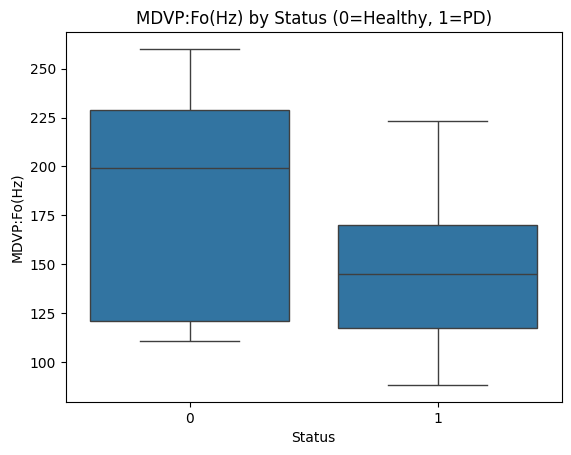

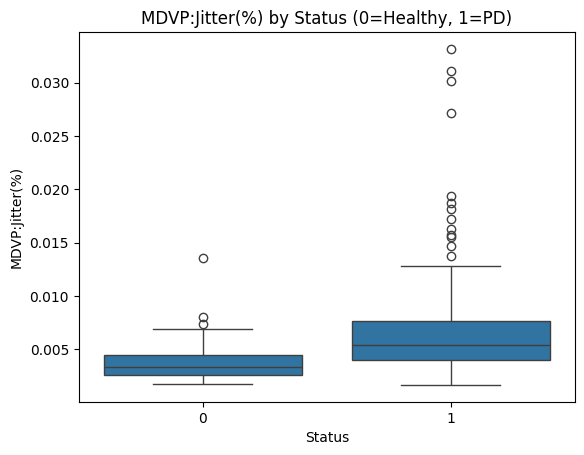

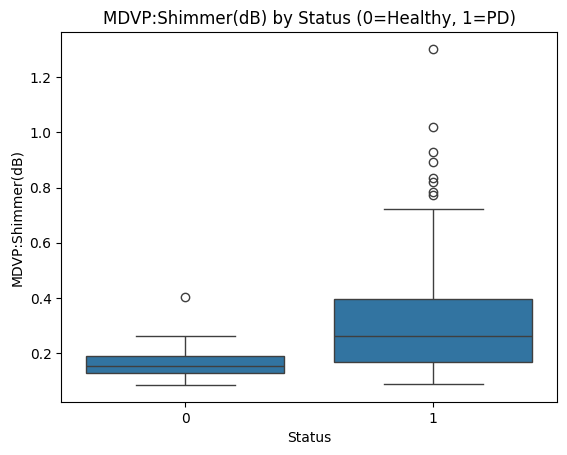

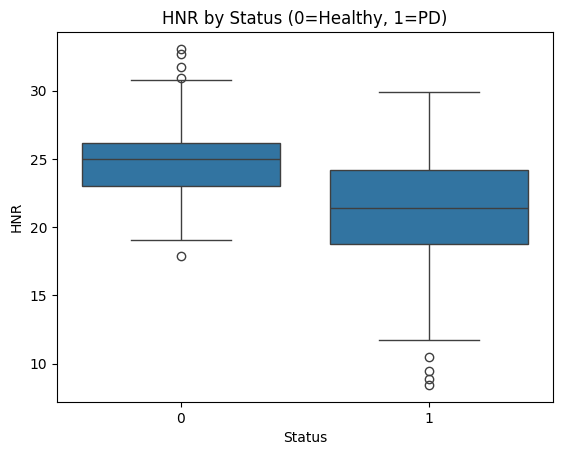

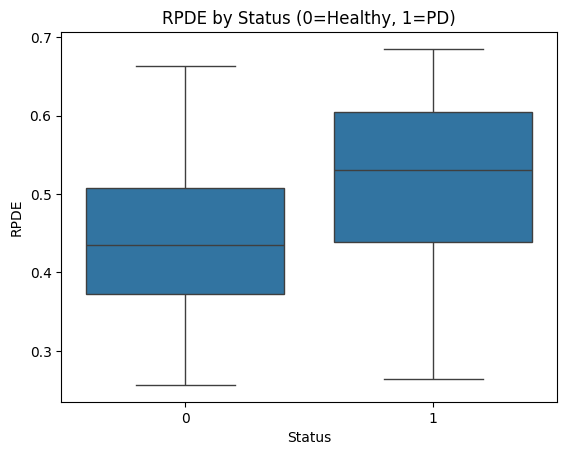

In [84]:
# Comparing feature patterns between healthy vs PD

# We use boxplots for a few representative features to see how
# their distributions differ between status = 0 and status = 1.
# This covers "comparing patterns between healthy and affected groups".

cols_to_plot = []

for col in ["MDVP:Fo(Hz)", "MDVP:Jitter(%)", "MDVP:Shimmer(dB)", "HNR", "RPDE"]:
    if col in voice_df.columns:
        cols_to_plot.append(col)

print("Features chosen for comparison:", cols_to_plot)

for col in cols_to_plot:
    plt.figure()
    sns.boxplot(data=voice_df, x=target_col, y=col)
    plt.title(f"{col} by Status (0=Healthy, 1=PD)")
    plt.xlabel("Status")
    plt.ylabel(col)
    plt.show()

Features used in correlation heatmap: ['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer(dB)', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'PPE']


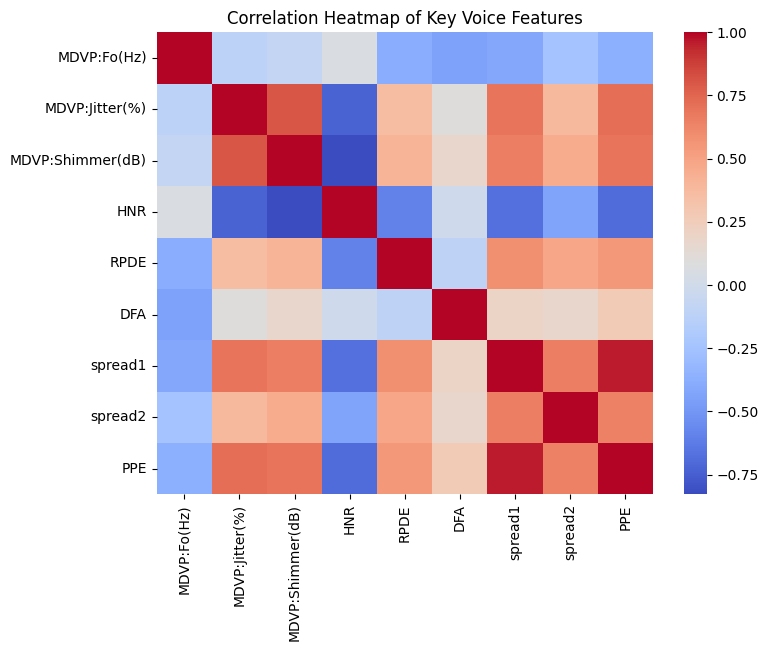

In [85]:
# Correlation heatmap for selected features

# We look at how some important voice features correlate with each other.
# This gives a sense of redundancy and patterns in the high-dimensional space.

selected_for_corr = cols_to_plot.copy()

# Add a few nonlinear features if they exist
for col in nonlinear_cols:
    if col not in selected_for_corr:
        selected_for_corr.append(col)

# Keep only columns that really exist
selected_for_corr = [c for c in selected_for_corr if c in voice_df.columns]

print("Features used in correlation heatmap:", selected_for_corr)

corr_matrix = voice_df[selected_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap of Key Voice Features")
plt.show()

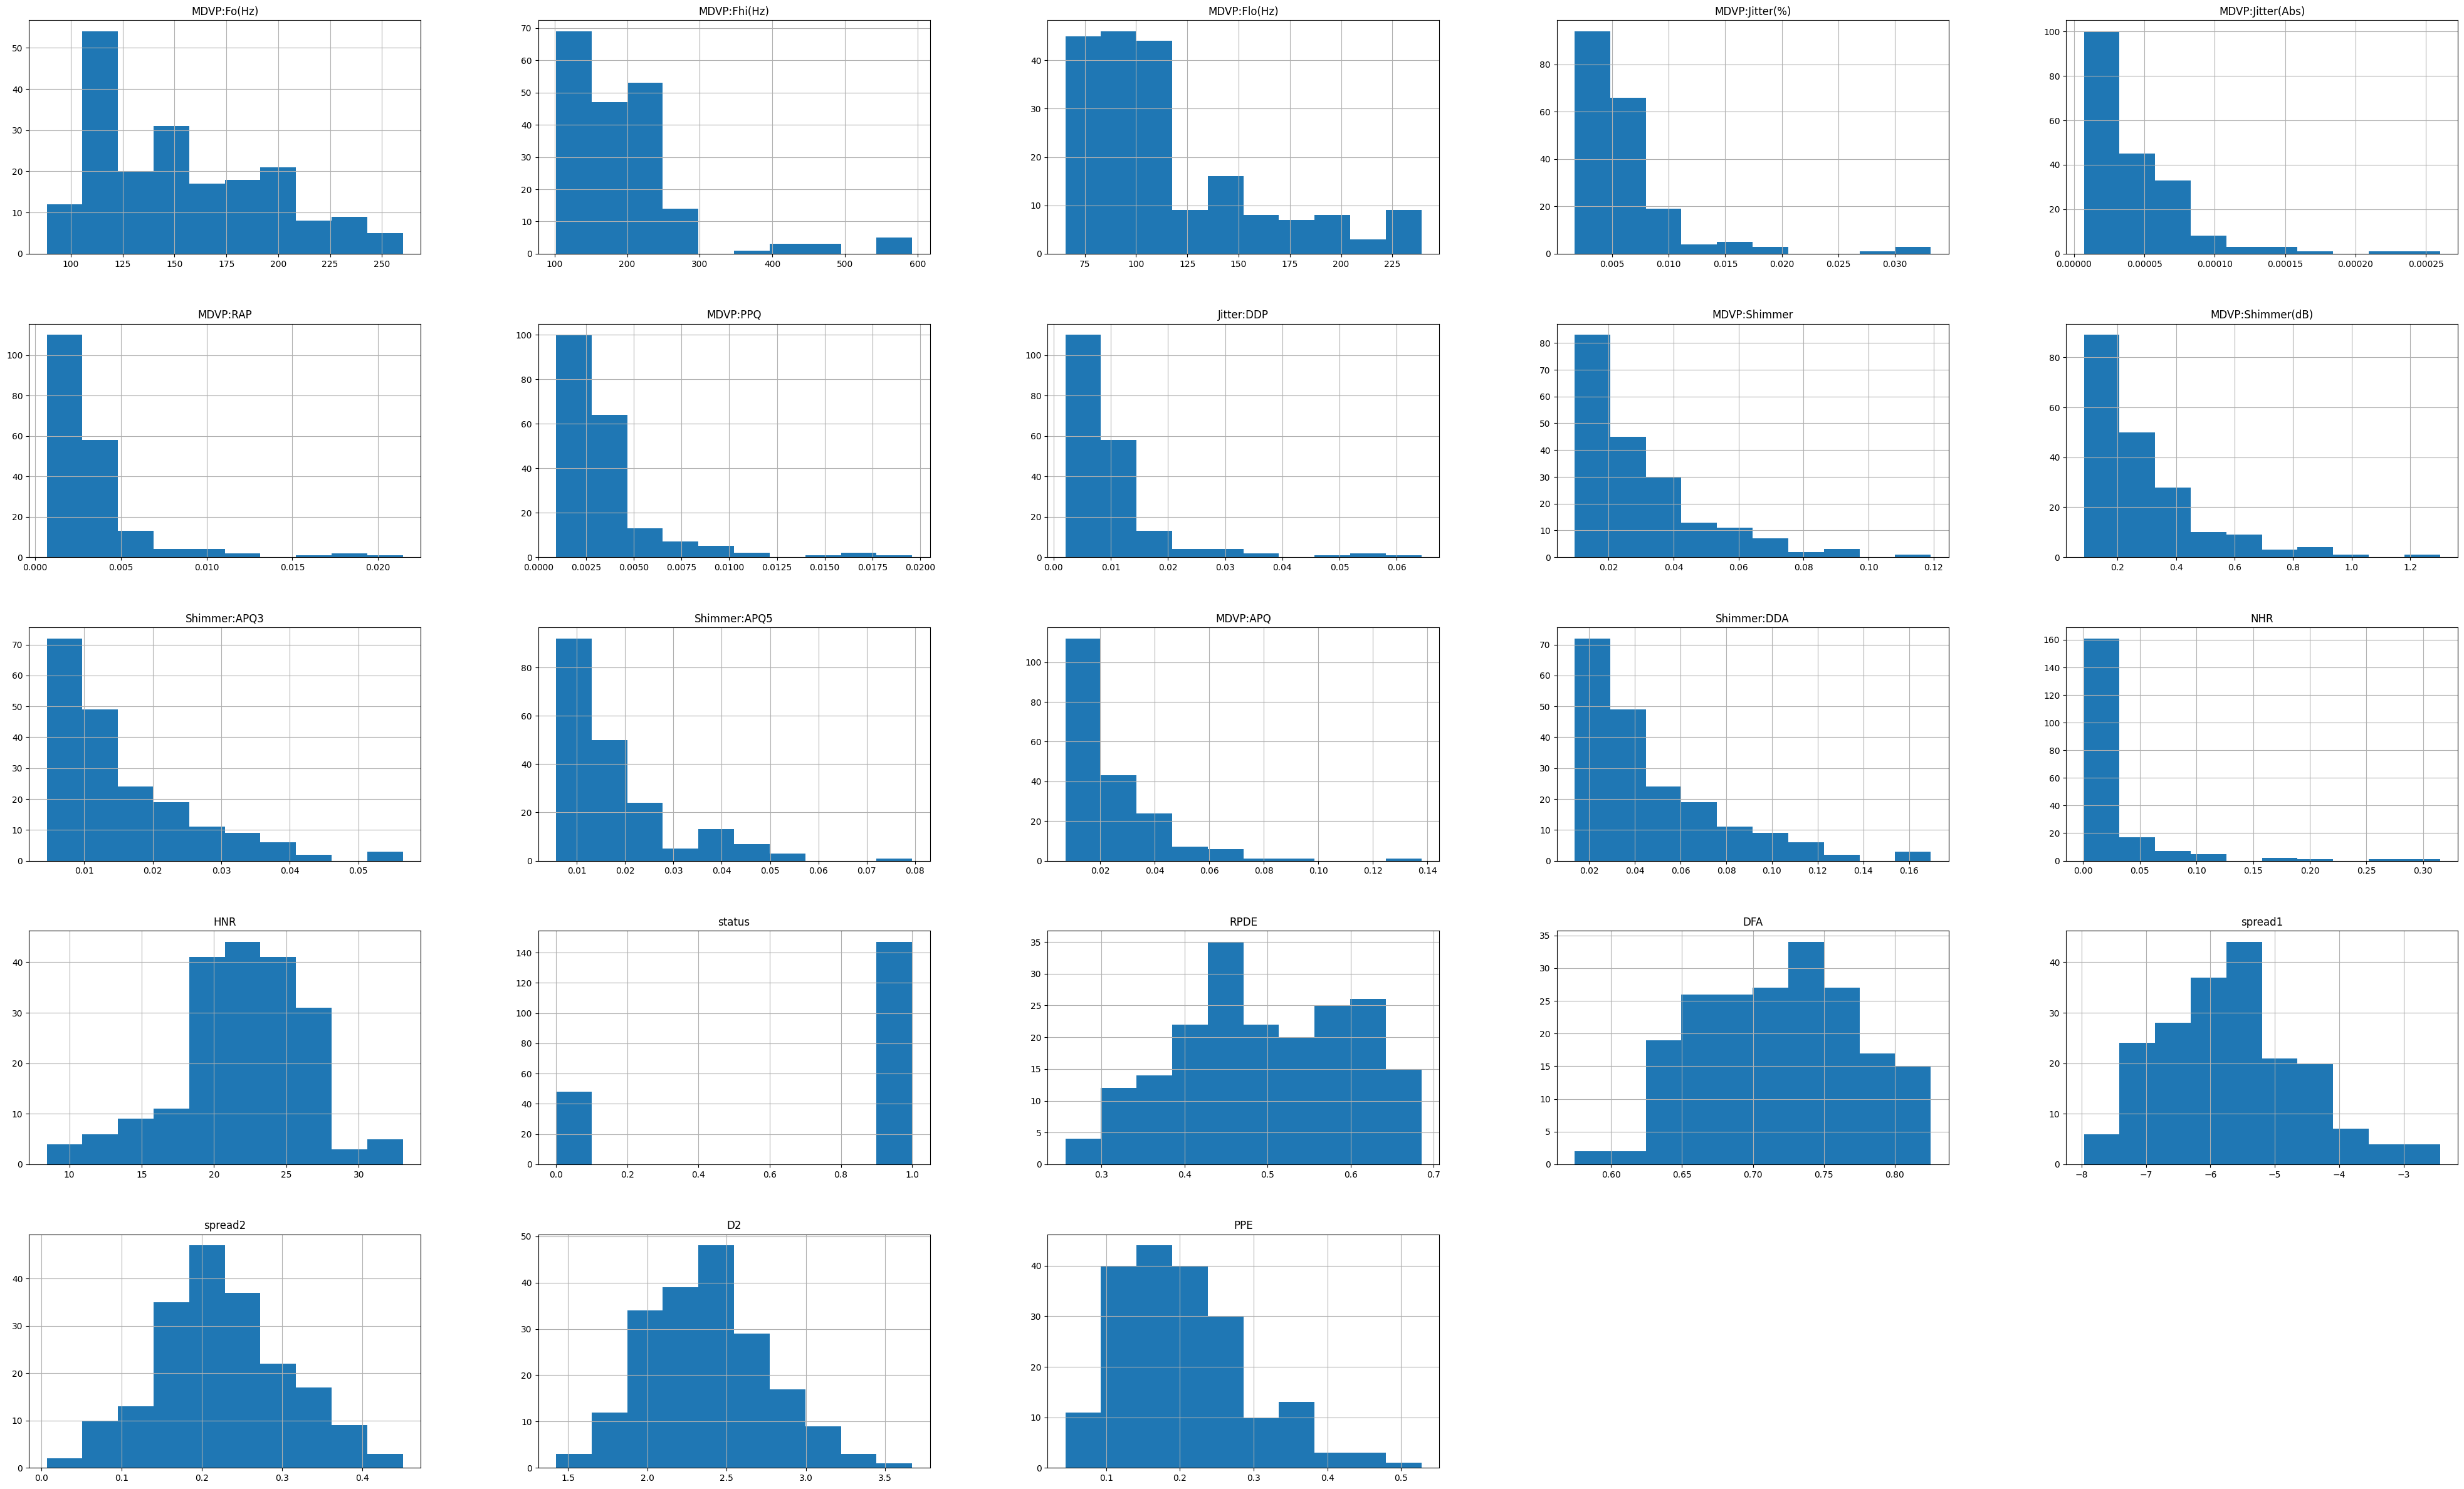

In [86]:
# Additional EDA Visualizations

# These plots help visualize how key voice features differ between
# healthy and Parkinson's patients beyond the boxplots and heatmaps.

# 1. Plot distribution of features
voice_df.hist(figsize=(50,30))
plt.show()

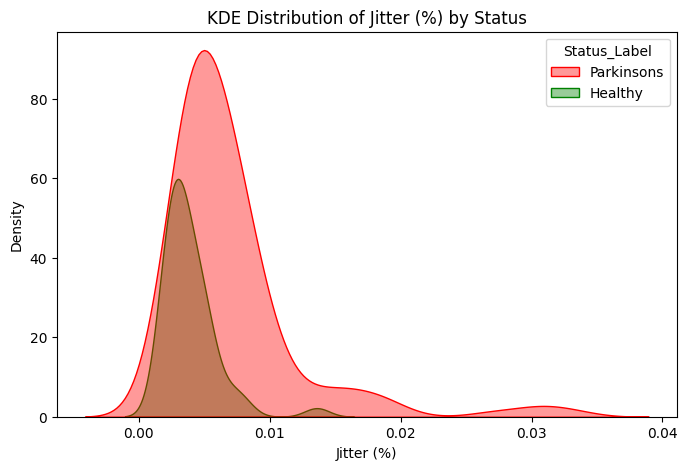

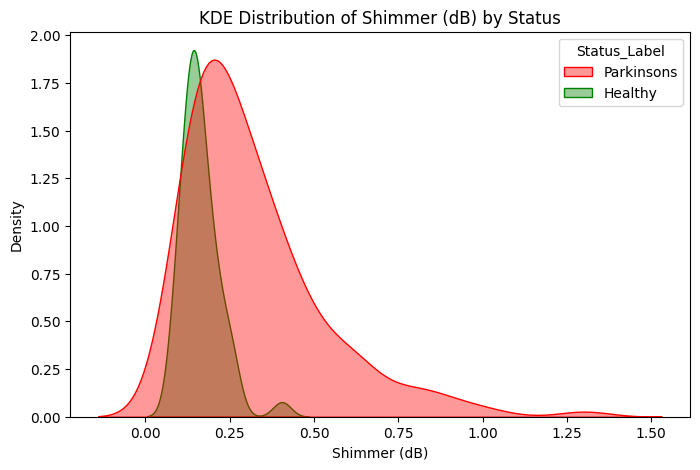

In [102]:
# 2. KDE distribution plots

# Generate the Status_Label column only for plotting
voice_df["Status_Label"] = voice_df["status"].map({0: "Healthy", 1: "Parkinsons"})

# Define a palette
palette = {"Healthy": "green", "Parkinsons": "red"}

# KDE for Jitter (%)
if "MDVP:Jitter(%)" in voice_df.columns:
    plt.figure(figsize=(8,5))
    sns.kdeplot(
        data=voice_df,
        x="MDVP:Jitter(%)",
        hue="Status_Label",
        fill=True,
        palette=palette,
        alpha=0.4
    )
    plt.title("KDE Distribution of Jitter (%) by Status")
    plt.xlabel("Jitter (%)")
    plt.ylabel("Density")
    plt.show()

# KDE for Shimmer (dB)
if "MDVP:Shimmer(dB)" in voice_df.columns:
    plt.figure(figsize=(8,5))
    sns.kdeplot(
        data=voice_df,
        x="MDVP:Shimmer(dB)",
        hue="Status_Label",
        fill=True,
        palette=palette,
        alpha=0.4
    )
    plt.title("KDE Distribution of Shimmer (dB) by Status")
    plt.xlabel("Shimmer (dB)")
    plt.ylabel("Density")
    plt.show()

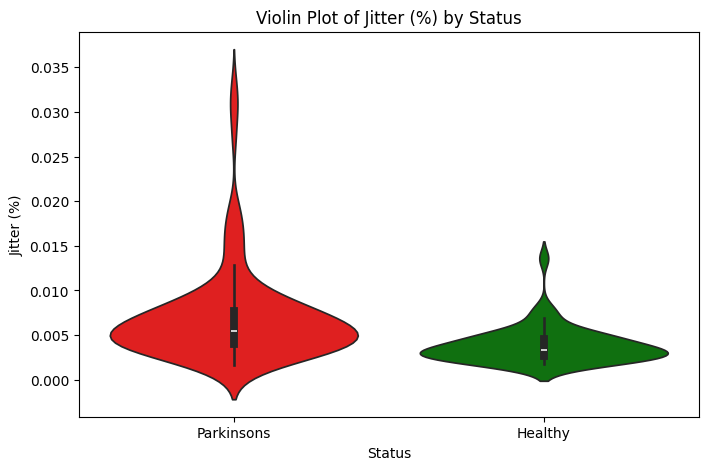

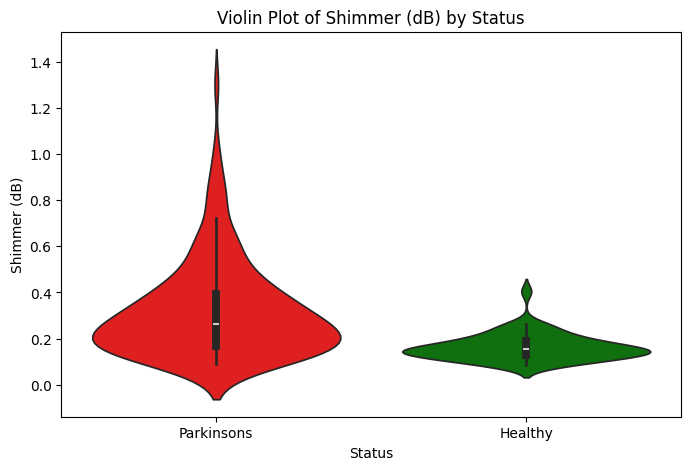

In [103]:
# 3. Violin plots

# Violin plot for Jitter (%)
if "MDVP:Jitter(%)" in voice_df.columns:
    plt.figure(figsize=(8,5))
    sns.violinplot(
        data=voice_df,
        x="Status_Label",
        y="MDVP:Jitter(%)",
        palette=palette
    )
    plt.title("Violin Plot of Jitter (%) by Status")
    plt.xlabel("Status")
    plt.ylabel("Jitter (%)")
    plt.show()

# Violin plot for Shimmer (dB)
if "MDVP:Shimmer(dB)" in voice_df.columns:
    plt.figure(figsize=(8,5))
    sns.violinplot(
        data=voice_df,
        x="Status_Label",
        y="MDVP:Shimmer(dB)",
        palette=palette
    )
    plt.title("Violin Plot of Shimmer (dB) by Status")
    plt.xlabel("Status")
    plt.ylabel("Shimmer (dB)")
    plt.show()

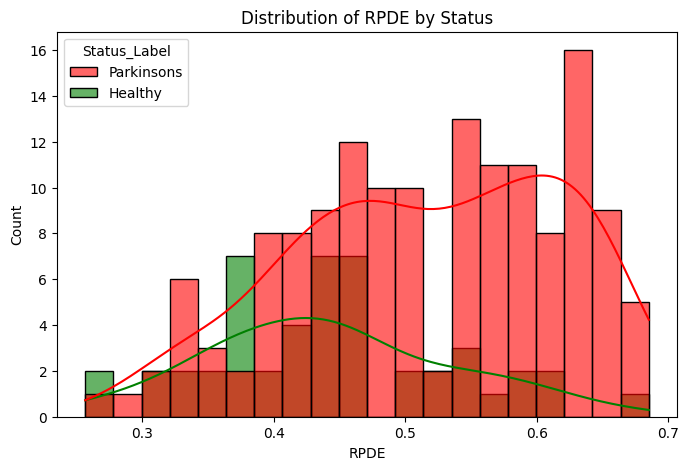

In [104]:
# 4. Histogram + KDE for RPDE

if "RPDE" in voice_df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(
        data=voice_df,
        x="RPDE",
        hue="Status_Label",
        bins=20,
        kde=True,
        palette=palette,
        alpha=0.6
    )
    plt.title("Distribution of RPDE by Status")
    plt.xlabel("RPDE")
    plt.ylabel("Count")
    plt.show()

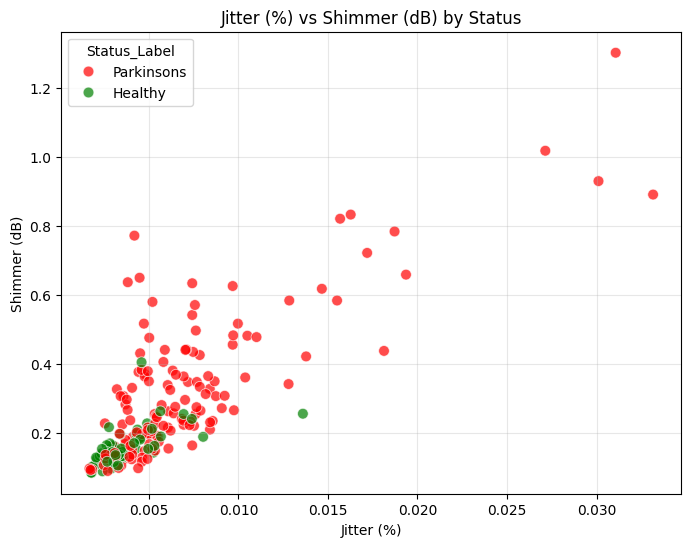

In [105]:
# 5. Scatterplot of Jitter vs Shimmer

if "MDVP:Jitter(%)" in voice_df.columns and "MDVP:Shimmer(dB)" in voice_df.columns:
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=voice_df,
        x="MDVP:Jitter(%)",
        y="MDVP:Shimmer(dB)",
        hue="Status_Label",
        palette=palette,
        alpha=0.7,
        s=60
    )
    plt.title("Jitter (%) vs Shimmer (dB) by Status")
    plt.xlabel("Jitter (%)")
    plt.ylabel("Shimmer (dB)")
    plt.grid(alpha=0.3)
    plt.show()

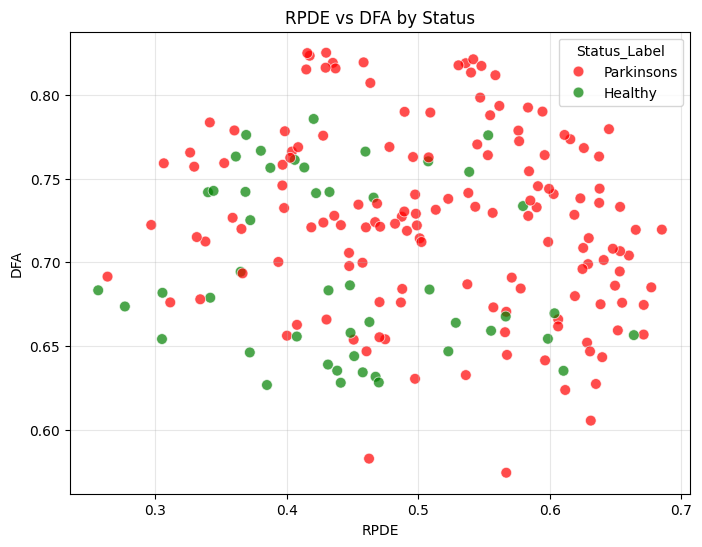

In [106]:
# 6. Scatterplot of RPDE vs DFA

if "RPDE" in voice_df.columns and "DFA" in voice_df.columns:
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=voice_df,
        x="RPDE",
        y="DFA",
        hue="Status_Label",
        palette=palette,
        alpha=0.7,
        s=60
    )
    plt.title("RPDE vs DFA by Status")
    plt.xlabel("RPDE")
    plt.ylabel("DFA")
    plt.grid(alpha=0.3)
    plt.show()

In [107]:
# Checking and handling missing values

# Even though the classic UCI dataset usually has no missing values,
# in general we should handle them. Here we fill numeric columns with
# the median to avoid losing rows.

print("Missing values per column BEFORE filling:")
print(voice_df.isna().sum())

numeric_cols = voice_df.select_dtypes(include=["number"]).columns.tolist()

for col in numeric_cols:
    median_val = voice_df[col].median()
    voice_df[col] = voice_df[col].fillna(median_val)

print("\nMissing values per column AFTER filling:")
print(voice_df.isna().sum())

Missing values per column BEFORE filling:
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
Status_Label        0
mean_jitter         0
mean_shimmer        0
HNR_to_NHR          0
dtype: int64

Missing values per column AFTER filling:
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
M

In [124]:
# Feature engineering for Parkinson's voice

# We add a few summary features:
# - mean_jitter: average of jitter-related columns
# - mean_shimmer: average of shimmer-related columns
# - HNR_to_NHR: ratio of harmonics to noise

# These help capture overall instability and noise in the voice signal.

if len(jitter_cols) > 0:
    voice_df["mean_jitter"] = voice_df[jitter_cols].mean(axis=1)

if len(shimmer_cols) > 0:
    voice_df["mean_shimmer"] = voice_df[shimmer_cols].mean(axis=1)

if "HNR" in voice_df.columns and "NHR" in voice_df.columns:
    voice_df["HNR_to_NHR"] = voice_df["HNR"] / (voice_df["NHR"] + 1e-6)

print("Columns after feature engineering:")
print(voice_df.columns)

Columns after feature engineering:
Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE', 'Status_Label', 'mean_jitter',
       'mean_shimmer', 'HNR_to_NHR'],
      dtype='object')


In [109]:
# Defining patient groups to prevent data leakage

# In this dataset, each subject may have multiple voice recordings (rows).
# If we randomly split rows, the same person might appear in both train and test,
# which leads to overly optimistic performance.

# To avoid this, we use 'name' as a group ID so that all recordings from the same
# person go either to the training set or the test set, but not both.

if "name" in voice_df.columns:
    groups = voice_df["name"]
    print("Number of unique patients (name):", groups.nunique())
else:
    # If there is no subject ID, we fall back to using the row index as group.
    # This is not ideal, but at least the code still runs.
    groups = pd.Series(np.arange(len(voice_df)))
    print("No 'name' column found. Using row index as group ID.")

Number of unique patients (name): 195


In [110]:
# Defining feature matrix X and target vector y

# We drop the ID column(s) and the target column, and keep the rest as features.

id_cols = ["name"] if "name" in voice_df.columns else []
X = voice_df.drop(columns=id_cols + [target_col])
y = voice_df[target_col]

print("Shape of X (features):", X.shape)
print("Shape of y (labels):", y.shape)

Shape of X (features): (195, 26)
Shape of y (labels): (195,)


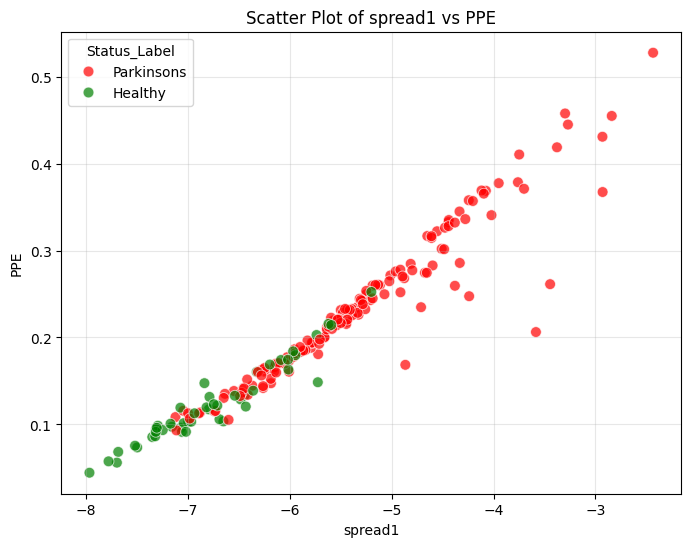

In [111]:
# Scatterplot for the two top correlated features

# Ensure X does not contain Status_Label
if "Status_Label" in X.columns:
    X = X.drop(columns=["Status_Label"])

# Compute correlations
corr_with_target = X.corrwith(y).sort_values(ascending=False)

# Select top two numeric features
top_feat_1 = corr_with_target.index[0]
top_feat_2 = corr_with_target.index[1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=voice_df,
    x=top_feat_1,
    y=top_feat_2,
    hue="Status_Label",
    palette=palette,
    s=60,
    alpha=0.7
)
plt.title(f"Scatter Plot of {top_feat_1} vs {top_feat_2}")
plt.xlabel(top_feat_1)
plt.ylabel(top_feat_2)
plt.grid(alpha=0.3)
plt.show()

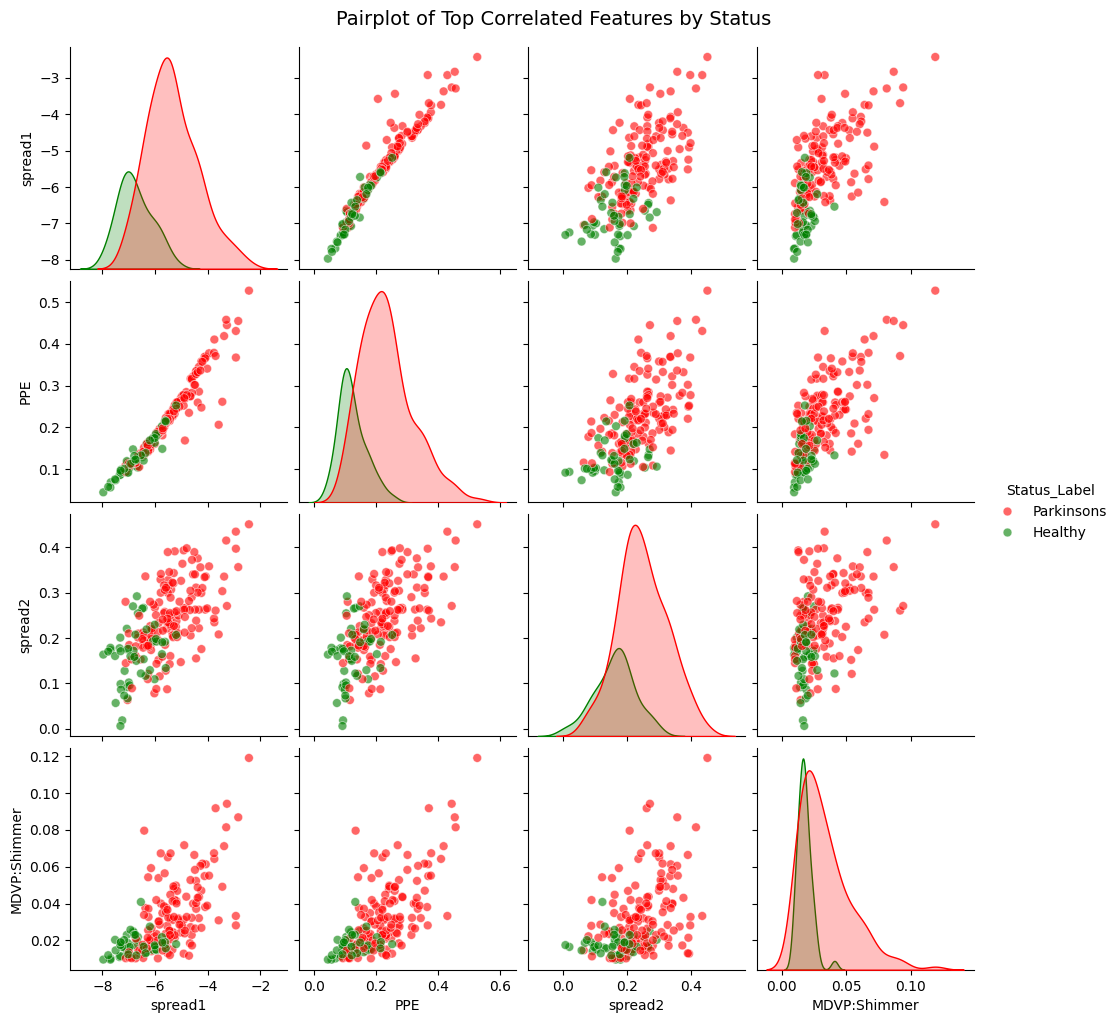

In [113]:
# Pairplot of top correlated features

# Compute correlation of each feature in X with target y
corr_with_target = X.corrwith(y).dropna().sort_values(ascending=False)

# If there are fewer than 2 numeric features, stop
if len(corr_with_target) < 2:
    print("Not enough numeric features to create a pairplot.")
else:
    # Select top 4 most correlated features (or fewer if dataset is small)
    num_feats = min(4, len(corr_with_target))
    top_features = corr_with_target.index[:num_feats].tolist()

    # Make sure these features actually exist in voice_df
    existing_features = [f for f in top_features if f in voice_df.columns]

    if len(existing_features) < 2:
        print("Not enough overlapping features between X and voice_df for pairplot.")
        print("Top features found in X:", top_features)
        print("Existing in voice_df:", existing_features)
    else:
        # Prepare dataframe for pairplot
        pair_plot_data = voice_df[existing_features + ["Status_Label"]].copy()

        # Draw pairplot
        g = sns.pairplot(
            pair_plot_data,
            hue="Status_Label",
            palette=pair_palette,
            diag_kind="kde",
            plot_kws={"alpha": 0.6, "s": 40}
        )
        g.fig.suptitle("Pairplot of Top Correlated Features by Status", fontsize=14, y=1.02)
        plt.show()

In [114]:
# Group-aware train–test split (no same patient in both sets)

# We use GroupShuffleSplit so that subject groups are kept separate.
# This directly addresses the requirement to avoid bias when
# multiple recordings come from the same person.

RANDOM_STATE = 42

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

for train_idx, test_idx in gss.split(X, y, groups=groups):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]
    groups_test = groups.iloc[test_idx]

print("Training set shape:", X_train.shape)
print("Test set shape    :", X_test.shape)

print("\nUnique patients in TRAIN:", groups_train.nunique())
print("Unique patients in TEST :", groups_test.nunique())
print("Overlap in patients between TRAIN and TEST:",
      len(set(groups_train) & set(groups_test)))

Training set shape: (156, 25)
Test set shape    : (39, 25)

Unique patients in TRAIN: 156
Unique patients in TEST : 39
Overlap in patients between TRAIN and TEST: 0


In [115]:
# Applying SMOTE to balance classes

print("\nApplying SMOTE to balance the training dataset...")

# Instantiate SMOTE (you can set random_state for reproducibility)
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training set
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nSMOTE successfully applied. Training dataset is now balanced.")


Applying SMOTE to balance the training dataset...
Before SMOTE:
status
1    115
0     41
Name: count, dtype: int64

After SMOTE:
status
1    115
0    115
Name: count, dtype: int64

SMOTE successfully applied. Training dataset is now balanced.


In [116]:
# Scaling features using StandardScaler

# Voice features have different units and ranges (Hz, %, dB, etc.).
# Standardization (mean 0, std 1) helps models like SVM and Logistic Regression
# to converge faster and perform better.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Example original feature values (first row):")
print(X_train.iloc[0, :5].values)

print("\nExample scaled feature values (first row):")
print(X_train_scaled[0, :5])

Example original feature values (first row):
[1.19992e+02 1.57302e+02 7.49970e+01 7.84000e-03 7.00000e-05]

Example scaled feature values (first row):
[-0.81514862 -0.40502529 -1.01614066  0.33017976  0.72802884]


In [117]:
# Defining models for Parkinson's voice screening

# All of these work well on dense numeric feature sets:
# - Logistic Regression: linear, interpretable coefficients
# - Random Forest: non-linear, good for feature importance
# - SVM (RBF): non-linear, strong performance on high-dimensional numeric data

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),
    "SVM (RBF)": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

print("Models defined:")
for name in models:
    print("-", name)

Models defined:
- Logistic Regression
- Random Forest
- SVM (RBF)


In [118]:
# Training and evaluating models on the test set

# For each model, we compute:
# - Accuracy
# - Precision
# - Recall (sensitivity)
# - F1-score
# - ROC-AUC

# In screening tasks, recall and F1 are especially important because
# we want to catch as many true Parkinson's cases as possible.

results = {}
y_pred_store = {}
y_prob_store = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_store[name] = y_pred

    # Probabilities (for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        y_prob_store[name] = y_prob
    else:
        y_prob = None
        y_prob_store[name] = None

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    results[name] = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc
    }

results_df = pd.DataFrame(results).T
print("\n=== Model performance on test set ===")
display(results_df)


Training Logistic Regression...

Training Random Forest...

Training SVM (RBF)...

=== Model performance on test set ===


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.871795,0.909091,0.93750,0.923077,0.861607
Random Forest,0.923077,0.939394,0.96875,0.953846,0.955357
SVM (RBF),0.923077,0.939394,0.96875,0.953846,0.928571


In [119]:
# Group-based cross-validation on training set (optional but good)

# Here we do a simple GroupKFold on the training data to see
# how stable the best model is across different patient splits.

gkf = GroupKFold(n_splits=5)

cv_scores = {}

for name, model in models.items():
    fold_f1 = []
    for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(X_train_scaled, y_train, groups=groups_train)):
        X_tr_fold = X_train_scaled[tr_idx]
        X_val_fold = X_train_scaled[val_idx]
        y_tr_fold = y_train.iloc[tr_idx]
        y_val_fold = y_train.iloc[val_idx]

        model.fit(X_tr_fold, y_tr_fold)
        y_val_pred = model.predict(X_val_fold)
        f1_fold = f1_score(y_val_fold, y_val_pred)
        fold_f1.append(f1_fold)

    cv_scores[name] = np.mean(fold_f1)

print("Mean F1-score across folds (training set, group-aware CV):")
for name, score in cv_scores.items():
    print(f"{name}: {score:.3f}")

Mean F1-score across folds (training set, group-aware CV):
Logistic Regression: 0.855
Random Forest: 0.936
SVM (RBF): 0.856


Best model (by test F1-score): Random Forest

=== Classification report (0=Healthy, 1=PD) ===
              precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.94      0.97      0.95        32

    accuracy                           0.92        39
   macro avg       0.89      0.84      0.86        39
weighted avg       0.92      0.92      0.92        39

ROC-AUC: 0.9553571428571428


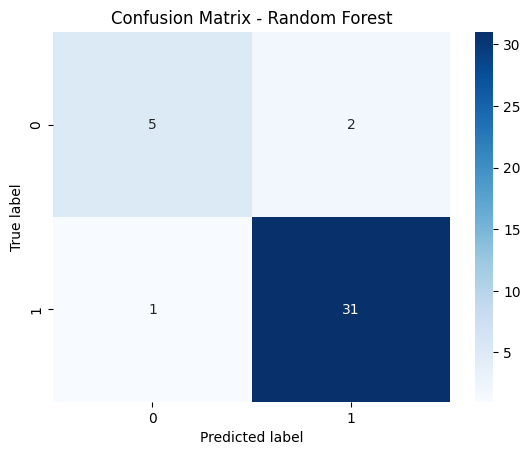

In [120]:
# Selecting best model and show confusion matrix + report

# We choose the best model based on F1-score on the test set,
# then show a detailed classification report and confusion matrix.

best_model_name = results_df["f1"].idxmax()
best_model = models[best_model_name]

print("Best model (by test F1-score):", best_model_name)

y_pred_best = y_pred_store[best_model_name]
y_prob_best = y_prob_store[best_model_name]

print("\n=== Classification report (0=Healthy, 1=PD) ===")
print(classification_report(y_test, y_pred_best))

if y_prob_best is not None:
    roc_best = roc_auc_score(y_test, y_prob_best)
    print("ROC-AUC:", roc_best)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

Top 15 features by importance:


spread1         0.136299
PPE             0.113287
MDVP:APQ        0.059658
MDVP:Fhi(Hz)    0.059251
Jitter:DDP      0.055019
Shimmer:APQ5    0.053270
spread2         0.050332
MDVP:Fo(Hz)     0.047603
D2              0.039011
MDVP:RAP        0.038149
MDVP:Flo(Hz)    0.034060
MDVP:PPQ        0.032298
HNR_to_NHR      0.028313
DFA             0.028026
MDVP:Shimmer    0.027282
dtype: float64

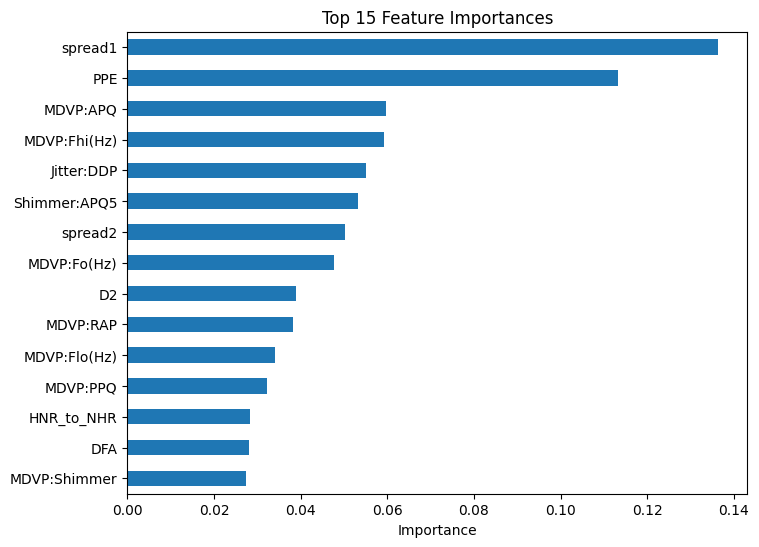

In [121]:
# Feature importance for clinical interpretation

# Random Forest (and other tree-based models) exposes feature_importances_.
# We can use this to see which voice features contribute most to predicting PD.
# If jitter and shimmer features appear near the top, it supports the idea
# that speech instability is strongly associated with Parkinsonian dysphonia.

# If the best model is not tree-based, we still use Random Forest for interpretation.

model_for_importance = best_model

if not hasattr(model_for_importance, "feature_importances_"):
    # fall back to Random Forest if needed
    rf_model = models.get("Random Forest", None)
    if rf_model is not None and hasattr(rf_model, "feature_importances_"):
        model_for_importance = rf_model
        print("Using Random Forest for feature importance interpretation.")
    else:
        model_for_importance = None

if model_for_importance is not None:
    importances = pd.Series(model_for_importance.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)

    print("Top 15 features by importance:")
    display(importances.head(15))

    plt.figure(figsize=(8, 6))
    importances.head(15).plot(kind="barh")
    plt.gca().invert_yaxis()
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.show()

else:
    print("No feature_importances_ available for interpretation.")

# Clinical Interpretation of Key Voice Features

The most important features identified by the model correspond to known acoustic biomarkers of Parkinson’s disease. Below is a brief interpretation of the top-ranked features:

- **spread1 / spread2**  
  Nonlinear measures describing the spread of the spectral energy distribution. Parkinson’s disease reduces vocal complexity and alters articulation, which changes these values.

- **PPE (Pitch Period Entropy)**  
  Measures unpredictability in pitch. PD increases pitch variability due to unstable vocal fold control.

- **MDVP:APQ / MDVP:Shimmer / Shimmer:APQ5**  
  Amplitude perturbation measures (shimmer). Elevated shimmer levels indicate inconsistent vocal fold closure, commonly seen in PD.

- **Jitter:DDP**  
  Frequency perturbation. PD patients typically exhibit cycle-to-cycle frequency instability because of impaired motor control.

- **MDVP:Fhi(Hz), MDVP:Flo(Hz), MDVP:Fo(Hz)**  
  Maximum, minimum, and average pitch. PD reduces pitch range and introduces irregular fluctuations.

- **D2 (Correlation Dimension)**  
  A nonlinear complexity measure. PD reduces neuromuscular control, lowering the complexity of the voice signal.

- **MDVP:RAP / MDVP:PPQ**  
  Measures of short-term amplitude and pitch stability. Higher values reflect tremor-like instability typical of PD.

- **HNR_to_NHR (Harmonics-to-Noise Ratio)**  
  PD voices have more noise and breathiness, leading to lower harmonic structure.

- **DFA (Detrended Fluctuation Analysis)**  
  Another nonlinear metric that captures long-term fluctuations. PD affects the structure of vocal fold vibration, altering DFA patterns.

## Summary

These features align with well-established acoustic markers of Parkinson’s disease. The model therefore relies on clinically meaningful characteristics of the voice rather than arbitrary patterns. This strengthens trust and supports its use as a screening aid, not a replacement for clinical diagnosis.

In [122]:
# Saving the scaler and best model
# Saving the feature names as well (useful for prediction input order)

# This shows how the trained screening model could be deployed.
# At prediction time, we would:
# - load the scaler
# - transform new voice features
# - load the model and compute a risk score.

import joblib

model_filename = "parkinsons_voice_model.pkl"
scaler_filename = "voice_feature_scaler.pkl"
feature_names_filename = "feature_names.pkl"

joblib.dump(best_model, model_filename)
joblib.dump(scaler, scaler_filename)
joblib.dump(list(X.columns), feature_names_filename)

print(f"Model saved as: {model_filename}")
print(f"Scaler saved as: {scaler_filename}")
print(f"Feature names saved as: {feature_names_filename}")
print("\nBest model and preprocessing objects saved successfully.")
print(f"\nExpected features for predictions ({len(X.columns)} total):")
print(list(X.columns))

Model saved as: parkinsons_voice_model.pkl
Scaler saved as: voice_feature_scaler.pkl
Feature names saved as: feature_names.pkl

Best model and preprocessing objects saved successfully.

Expected features for predictions (25 total):
['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE', 'mean_jitter', 'mean_shimmer', 'HNR_to_NHR']


In [123]:
# Deployment simulation

# Load saved model, scaler, and feature names
loaded_model = joblib.load('parkinsons_voice_model.pkl')
loaded_scaler = joblib.load('voice_feature_scaler.pkl')
loaded_features = joblib.load('feature_names.pkl')

print("Model, scaler, and feature names loaded successfully\n")

# Simulate predictions on test set
print("Making predictions on test set...")

y_pred_deploy = loaded_model.predict(X_test_scaled)
y_pred_proba_deploy = loaded_model.predict_proba(X_test_scaled)

# Create predictions dataframe
predictions_df = pd.DataFrame({
    'Sample_ID': range(len(X_test)),
    'Prediction': y_pred_deploy,
    'Prediction_Label': ['Healthy' if p == 0 else 'Parkinson\'s' for p in y_pred_deploy],
    'Prob_Healthy': y_pred_proba_deploy[:, 0],
    'Prob_Parkinsons': y_pred_proba_deploy[:, 1],
    'Confidence': y_pred_proba_deploy.max(axis=1),
    'Actual': y_test.values
})

print("\nFirst 10 Predictions:")
print(predictions_df.head(10))

# Summary statistics
print("\nPrediction Summary:")
print(f"Total test samples: {len(predictions_df)}")
print(f"Predicted Healthy: {(predictions_df['Prediction'] == 0).sum()}")
print(f"Predicted Parkinson's: {(predictions_df['Prediction'] == 1).sum()}")
print(f"Average confidence: {predictions_df['Confidence'].mean():.4f}")
print(f"High confidence (>0.9) predictions: {(predictions_df['Confidence'] > 0.9).sum()}")

# Save predictions
predictions_df.to_csv('parkinsons_predictions.csv', index=False)
print("\nPredictions saved to 'parkinsons_predictions.csv'")

Model, scaler, and feature names loaded successfully

Making predictions on test set...

First 10 Predictions:
   Sample_ID  Prediction Prediction_Label  Prob_Healthy  Prob_Parkinsons  \
0          0           1      Parkinson's         0.005            0.995   
1          1           1      Parkinson's         0.200            0.800   
2          2           1      Parkinson's         0.060            0.940   
3          3           1      Parkinson's         0.000            1.000   
4          4           1      Parkinson's         0.000            1.000   
5          5           1      Parkinson's         0.040            0.960   
6          6           0          Healthy         0.715            0.285   
7          7           0          Healthy         0.950            0.050   
8          8           1      Parkinson's         0.000            1.000   
9          9           1      Parkinson's         0.000            1.000   

   Confidence  Actual  
0       0.995       1  
1   

# Deployment Strategy for Mobile-Health / Clinical System

---

## 1. Integration into Clinical Workflow
- Embed the model into hospital/clinic **Electronic Health Record (EHR)** systems  
- Collect voice samples during **patient intake** or **routine clinical visits**  
- Perform **automated analysis**, with results available within seconds  

---

## 2. Alert and Recommendation System

### 🔴 High Risk  
**Criteria:** Confidence > 0.85 and Probability of Parkinson’s > 0.80  
- Immediate flag for **neurology consultation**  
- Alert sent to the **treating physician**  
- Patient advised to undergo **formal neurological evaluation**

### 🟠 Medium Risk  
**Criteria:** Confidence 0.70–0.85 and Probability 0.65–0.80  
- Schedule a **follow-up appointment**  
- Recommend **additional screening tests**  
- Monitor patient for **symptom progression**

### 🟢 Low Risk  
**Criteria:** Confidence < 0.70  
- Continue **routine monitoring**  
- Recommend **annual reassessment**

---

## 3. Mobile-Health Application
- User-friendly mobile app for **at-home voice recording**  
- **Real-time analysis** and feedback  
- **Longitudinal tracking** of voice changes over time  
- Integration with **wearable devices** (smartwatches, fitness trackers)  
- Push notifications for **concerning patterns**

---

## 4. Data Security and Privacy
- Encrypt all voice recordings and patient data (**HIPAA-compliant**)  
- Store models and data on **secure, on-premises servers**  
- Implement **multi-factor authentication** for healthcare providers  
- Maintain **audit logs** for all predictions and clinical decisions  
- Conduct regular **penetration testing** and security updates  

---

## 5. Model Maintenance and Monitoring
- Retrain the model **quarterly** using new patient cohorts  
- Monitor for **prediction drift** and model degradation  
- Perform **A/B testing** before deploying new versions  
- Maintain **version control** with comprehensive documentation  
- Track **real-world performance metrics** against validation results  

---

## 6. Regulatory and Ethical Considerations
- Follow **FDA clearance pathways** for clinical deployment  
- Obtain **informed consent** for patient data collection  
- Ensure transparency regarding **model limitations and false-positive rates**  
- Apply a **human-in-the-loop** approach: decision support, not replacement  
- Conduct regular **bias audits** across demographic groups  

---

## 7. Future Enhancements
- Multimodal analysis combining **voice, gait, tremor, and motor data**  
- Development of **personalized patient baselines**  
- Disease progression tracking and **outcome prediction**  
- Integration with **genetic and biomarker data** for comprehensive risk profiling  